<!-- reader-content -->

# Resolve and sweep a chip

Two multilevel transmons couple through a detuned bus resonator. Sweeping one
bare transmon frequency through the other reproduces Fig. 1 from the talk: the
bare declarations cross, while the dressed transitions remain separated by
twice the bus-mediated exchange rate.

quchip uses GHz for frequencies. The model below uses the same parameters as
the slide and applies `RWA()` in a rotating frame.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np

from quchip import RWA, Capacitive, Chip, DuffingTransmon, Resonator, SpectrumSweep, Sweep

q1_frequency = 5.30
q2_frequency0 = 5.58
bus_frequency = 6.55
q2_frequencies = np.linspace(5.255, 5.345, 181)
coupling_strength = 0.050

q1 = DuffingTransmon(
    freq=q1_frequency,
    anharmonicity=-0.65,
    levels=4,
    label="q1",
)
q2 = DuffingTransmon(
    freq=q2_frequency0,
    anharmonicity=-0.65,
    levels=4,
    label="q2",
)
bus = Resonator(freq=bus_frequency, levels=4, label="bus")
chip = Chip(
    [q1, q2, bus],
    couplings=[
        Capacitive(q1, bus, g=coupling_strength, label="q1-bus"),
        Capacitive(q2, bus, g=coupling_strength, label="q2-bus"),
    ],
    frame="rotating",
    approximation=RWA(),
)

/Users/fermious/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/br/2_469j7j7vg2p9r2p4x4zv240000gn/T/matplotlib-x8jgma2j because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


## Read the chip's statics

The declared frequencies are inputs. `chip.freq()` returns dressed
$0\rightarrow1$ transitions, while `chip.static_zz()` returns the conditional
two-qubit shift for this coupled model.

In [2]:
initial_dressed_frequencies = {
    "q1": float(chip.freq(q1)),
    "q2": float(chip.freq(q2)),
    "bus": float(chip.freq(bus)),
}
initial_static_zz = float(chip.static_zz(q1, q2))

The resolved Hamiltonian applies the chip's basis, frame, and approximation
strategy through the same public path used for simulation.

In [3]:
chip.hamiltonian()

PhysicsExpr(kind='add', args=(PhysicsExpr(kind='add', args=(PhysicsExpr(kind='add', args=(PhysicsExpr(kind='add', args=(PhysicsExpr(kind='scale', args=(PhysicsExpr(kind='literal', args=(1.0,), labels=()), PhysicsExpr(kind='matrix', args=(array([[ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
         0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j, -0.00414144+0.j,  0.        +0.j, ...,
         0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j, -0.00828288+0.j, ...,
         0.        +0.j,  0.        +0.j,  0.        +0.j],
       ...,
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
        -3.88907067+0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
         0.        +0.j, -3.89321211+0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
         0.        +0.j,  0.        +0.j, -3.89735355+0.j]],
     

`chip.resolve().dropped_terms_summary()` audits the RWA without reconstructing
the Hamiltonian by hand:

In [4]:
rwa_summary = chip.resolve().dropped_terms_summary()
rwa_summary

'4 term(s) dropped:\n  [q1-bus] coupling band (Δa=-1, Δb=-1) on q1·bus  (counter-rotating under RWA; amp 0.15 GHz, freq 11.8519 GHz)\n  [q1-bus] coupling band (Δa=+1, Δb=+1) on q1·bus  (counter-rotating under RWA; amp 0.15 GHz, freq 11.8519 GHz)\n  [q2-bus] coupling band (Δa=-1, Δb=-1) on q2·bus  (counter-rotating under RWA; amp 0.15 GHz, freq 12.1314 GHz)\n  [q2-bus] coupling band (Δa=+1, Δb=+1) on q2·bus  (counter-rotating under RWA; amp 0.15 GHz, freq 12.1314 GHz)'

## Sweep one bare frequency

`Sweep` names the public parameter path to vary. `SpectrumSweep` creates an
isolated chip at each point, so the original declaration remains unchanged.
Setting `overlap_threshold=0.0` keeps both intentionally hybridized
one-excitation labels available at the centre of the avoided crossing.

In [5]:
frequency_axis = Sweep(q2_frequencies, name="q2.freq")
sweep_result = SpectrumSweep(
    chip,
    [frequency_axis],
    evals_count=4,
    overlap_threshold=0.0,
).run(progress=False)

The two lowest excited eigenvalues are the qubit-like branches throughout this
window; the bus-like excitation remains far above them. Subtracting the ground
energy at each sweep point gives the two transition frequencies. The public
`dressed_index()` result tells us which branch is more $q_1$-like.

In [6]:
ground_energy = sweep_result.eigenvalues[:, 0]
qubit_branches = sweep_result.eigenvalues[:, 1:3] - ground_energy[:, None]
lower_branch = qubit_branches[:, 0]
upper_branch = qubit_branches[:, 1]
splitting = upper_branch - lower_branch
q1_branch = sweep_result.dressed_index(q1=1, q2=0, bus=0).astype(int) - 1

minimum_index = int(np.argmin(splitting))
minimum_splitting = float(splitting[minimum_index])
minimum_frequency = float(q2_frequencies[minimum_index])
inferred_exchange_rate = 0.5 * minimum_splitting
second_order_splitting_scale = 2.0 * coupling_strength**2 / abs(bus_frequency - q1_frequency)
relative_difference_to_second_order = (
    abs(minimum_splitting - second_order_splitting_scale) / minimum_splitting
)

if minimum_index in (0, len(q2_frequencies) - 1):
    raise RuntimeError("The avoided-crossing minimum lies at the sweep boundary.")
if not 4.3e-3 < minimum_splitting < 4.5e-3:
    raise RuntimeError("The resolved splitting does not reproduce the slide-scale exchange rate.")
if len(chip.resolve().dropped_terms) != 4:
    raise RuntimeError("The RWA ledger does not contain the four counter-rotating coupling bands.")
if chip.parameters["q2.freq"] != q2_frequency0:
    raise RuntimeError("SpectrumSweep mutated the original chip.")

## Interpret the avoided crossing

The dashed lines are the bare declarations. Red follows the more $q_1$-like
dressed transition, and black follows the more $q_2$-like transition. At the
crossing, the branches remain separated by $2J\approx4.4$ MHz. Second-order
dispersive perturbation theory gives $4.0$ MHz. The resolved spectrum includes
the higher-order dressing retained by this truncated model.

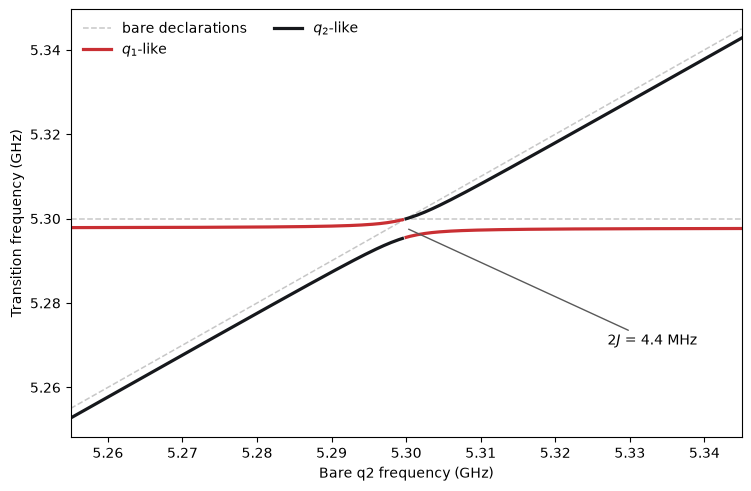

In [7]:
figure, axis = plt.subplots(figsize=(7.4, 4.8), layout="constrained")

axis.plot(q2_frequencies, q2_frequencies, color="0.78", linestyle="--", linewidth=1.1)
axis.axhline(q1_frequency, color="0.78", linestyle="--", linewidth=1.1, label="bare declarations")
for branch_index in (0, 1):
    q1_like = q1_branch == branch_index
    axis.plot(
        q2_frequencies,
        np.where(q1_like, qubit_branches[:, branch_index], np.nan),
        color="#C92F33",
        linewidth=2.3,
        label="$q_1$-like" if branch_index == 0 else None,
    )
    axis.plot(
        q2_frequencies,
        np.where(~q1_like, qubit_branches[:, branch_index], np.nan),
        color="#16181C",
        linewidth=2.3,
        label="$q_2$-like" if branch_index == 0 else None,
    )
axis.annotate(
    f"$2J$ = {1.0e3 * minimum_splitting:.1f} MHz",
    xy=(minimum_frequency, 0.5 * (lower_branch[minimum_index] + upper_branch[minimum_index])),
    xytext=(5.327, 5.270),
    arrowprops={"arrowstyle": "-", "color": "0.35"},
    fontsize=10,
)
axis.set(
    xlabel="Bare q2 frequency (GHz)",
    ylabel="Transition frequency (GHz)",
    xlim=(q2_frequencies[0], q2_frequencies[-1]),
)
axis.legend(frameon=False, ncols=2, loc="upper left")

figure_path = "../docs/images/resolve_and_sweep.png"
figure.savefig(figure_path, dpi=180)
plt.show()

The receipt records the exchange inferred from the avoided crossing, the
second-order scale, the approximation audit, and whether the original chip
kept its declared `q2` frequency.

In [8]:
statics_receipt = {
    "approximation": chip.settings["approximation"],
    "dressed_frequencies_ghz": initial_dressed_frequencies,
    "dropped_rwa_terms": len(chip.resolve().dropped_terms),
    "figure": figure_path,
    "full_dimension": int(np.prod(chip.dims)),
    "inferred_exchange_rate_mhz": 1.0e3 * inferred_exchange_rate,
    "minimum_at_bare_q2_ghz": minimum_frequency,
    "minimum_splitting_mhz": 1.0e3 * minimum_splitting,
    "original_chip_unchanged": bool(chip.parameters["q2.freq"] == q2_frequency0),
    "relative_difference_to_second_order": relative_difference_to_second_order,
    "second_order_splitting_scale_mhz": 1.0e3 * second_order_splitting_scale,
    "static_zz_khz": 1.0e6 * initial_static_zz,
    "sweep_points": len(q2_frequencies),
}

print(f"RESULT statics={json.dumps(statics_receipt, sort_keys=True, separators=(',', ':'))}")

RESULT statics={"approximation":"RWA","dressed_frequencies_ghz":{"bus":6.55414143998032,"q1":5.297749744925113,"q2":5.577226664394395},"dropped_rwa_terms":4,"figure":"../docs/images/resolve_and_sweep.png","full_dimension":64,"inferred_exchange_rate_mhz":2.204908100780223,"minimum_at_bare_q2_ghz":5.3,"minimum_splitting_mhz":4.409816201560446,"original_chip_unchanged":true,"relative_difference_to_second_order":0.09293271710857891,"second_order_splitting_scale_mhz":4.000000000000001,"static_zz_khz":22.604309073415152,"sweep_points":181}


## What to change

Change either bus coupling and rerun the sweep to see how the inferred exchange
changes. Moving the bus closer tests where the second-order dispersive scale
stops tracking the resolved avoided crossing.